In [ ]:
import os

raw_dir = "/content/drive/MyDrive/Các món ăn Việt/các món ăn Việt"

print("Các thư mục món ăn:")
for item in os.listdir(raw_dir):
    print(item)

Các thư mục món ăn:
bánh mì - Tìm trên Google
bánh xèo - Tìm trên Google
b├║n ─æa cua - T├¼m tr├¬n Google
b├║n b├▓ huß║┐ - T├¼m tr├¬n Google
bún chả hà nội - Tìm trên Google
b├ính x├¿o - T├¼m tr├¬n Google
bún bò huế - Tìm trên Google
b├ính m├¼ - T├¼m tr├¬n Google
bún đa cua - Tìm trên Google
b├║n chß║ú h├á nß╗Öi - T├¼m tr├¬n Google
cơm tấm - Tìm trên Google
phở - Tìm trên Google
c╞ím tß║Ñm - T├¼m tr├¬n Google
phß╗ƒ - T├¼m tr├¬n Google


In [ ]:
import os
import shutil
from PIL import Image

raw_dir = "/content/drive/MyDrive/Các món ăn Việt/các món ăn Việt"
clean_dir = "/content/clean_vietnamese_food"

valid_ext = [".jpg", ".jpeg", ".png", ".webp"]

class_map = {
    "bánh mì - Tìm trên Google": "banh_mi",
    "bánh xèo - Tìm trên Google": "banh_xeo",
    "bún bò huế - Tìm trên Google": "bun_bo_hue",
    "bún chả hà nội - Tìm trên Google": "bun_cha_ha_noi",
    "bún đa cua - Tìm trên Google": "bun_da_cua",
    "cơm tấm - Tìm trên Google": "com_tam",
    "phở - Tìm trên Google": "pho"
}

# Xóa folder clean cũ nếu có, để tránh bị copy trùng ảnh
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

os.makedirs(clean_dir, exist_ok=True)

for old_class, new_class in class_map.items():
    old_path = os.path.join(raw_dir, old_class)
    new_path = os.path.join(clean_dir, new_class)

    os.makedirs(new_path, exist_ok=True)

    count = 0

    if not os.path.exists(old_path):
        print("Không tìm thấy thư mục:", old_path)
        continue

    for file_name in os.listdir(old_path):
        file_path = os.path.join(old_path, file_name)
        ext = os.path.splitext(file_name)[1].lower()

        if ext in valid_ext:
            try:
                img = Image.open(file_path)
                img.verify()

                new_file_name = f"{new_class}_{count}{ext}"
                new_file_path = os.path.join(new_path, new_file_name)

                shutil.copy(file_path, new_file_path)
                count += 1

            except:
                pass

    print(new_class, ":", count, "ảnh")

banh_mi : 143 ảnh
banh_xeo : 126 ảnh
bun_bo_hue : 112 ảnh
bun_cha_ha_noi : 126 ảnh
bun_da_cua : 127 ảnh
com_tam : 131 ảnh
pho : 144 ảnh


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_width, img_height = 128, 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = datagen.flow_from_directory(
    clean_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    clean_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

print(train_generator.class_indices)

Found 730 images belonging to 7 classes.
Found 179 images belonging to 7 classes.
{'banh_mi': 0, 'banh_xeo': 1, 'bun_bo_hue': 2, 'bun_cha_ha_noi': 3, 'bun_da_cua': 4, 'com_tam': 5, 'pho': 6}


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(7, activation="softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,583 (16.36 MB)

 Trainable params: 4,288,583 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 829ms/step - accuracy: 0.1397 - loss: 2.0126 - val_accuracy: 0.2123 - val_loss: 1.9356
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 643ms/step - accuracy: 0.1671 - loss: 1.9369 - val_accuracy: 0.2514 - val_loss: 1.8946
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 610ms/step - accuracy: 0.2082 - loss: 1.9158 - val_accuracy: 0.2682 - val_loss: 1.8176
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 604ms/step - accuracy: 0.1863 - loss: 1.9014 - val_accuracy: 0.1788 - val_loss: 1.8609
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 613ms/step - accuracy: 0.2397 - loss: 1.8616 - val_accuracy: 0.2793 - val_loss: 1.7810
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 677ms/step - accuracy: 0.2603 - loss: 1.8375 - val_accuracy: 0.3352 - val_loss: 1.7425
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 612ms/step - accuracy: 0.3082 - loss: 1.7844 - val_accuracy: 0.3408 - val_loss: 1.6954
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 610ms/step - accuracy: 0.3110 - loss: 1.7465 - val_accu

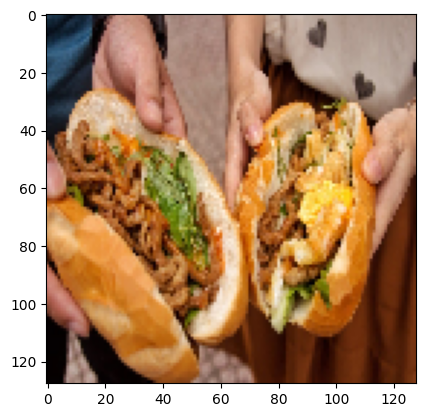

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Món ăn tiên đoán: banh_mi


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/banh_mi/banh_mi_103.jpg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

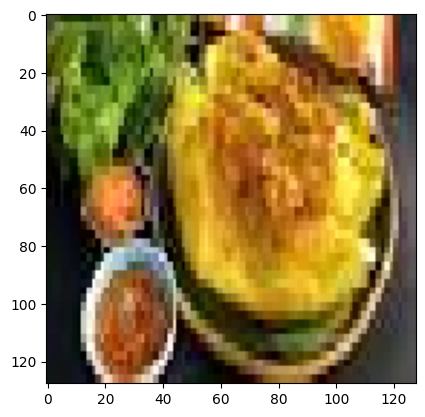

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Món ăn tiên đoán: banh_xeo


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/banh_xeo/banh_xeo_1.jpeg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

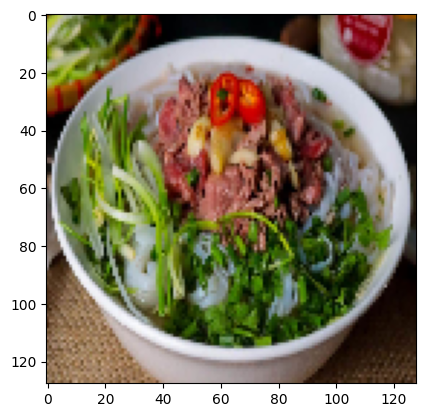

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Món ăn tiên đoán: pho


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/pho/pho_106.jpg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

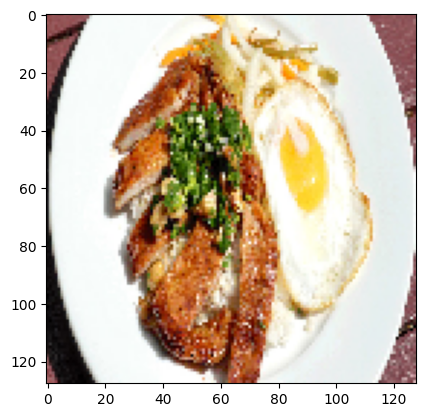

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Món ăn tiên đoán: com_tam


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/com_tam/com_tam_108.jpg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

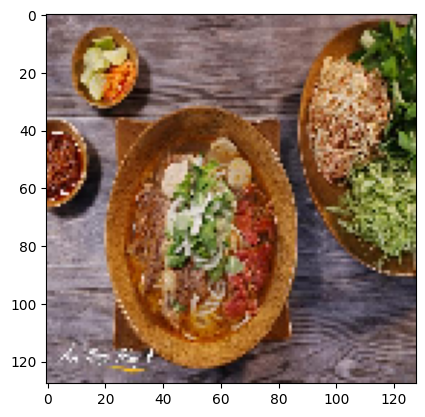

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Món ăn tiên đoán: bun_bo_hue


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/bun_bo_hue/bun_bo_hue_51.jpg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

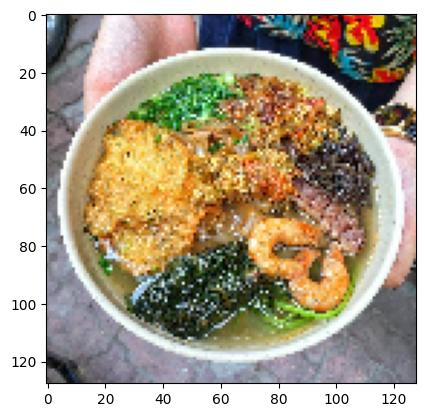

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Món ăn tiên đoán: bun_da_cua


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/bun_da_cua/bun_da_cua_40.jpg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

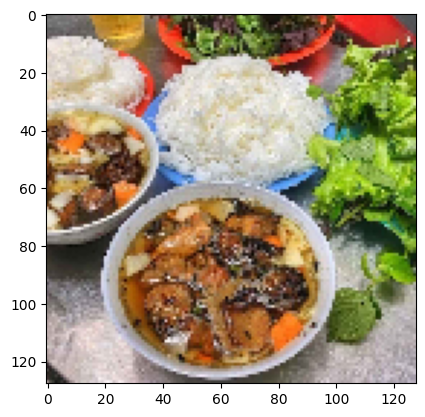

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Món ăn tiên đoán: bun_cha_ha_noi


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path= "/content/clean_vietnamese_food/bun_cha_ha_noi/bun_cha_ha_noi_101.jpg"
img= load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img= np.array(img)
img= img/255
img= img.reshape(1, 128, 128, 3)
prediction= np.argmax(model.predict(img))
class_labels= {v: k for k, v in train_generator.class_indices.items()}
dish_name= class_labels[prediction]
print(f'Món ăn tiên đoán: {dish_name}')

In [ ]:
import shutil

shutil.copytree(
    "/content/clean_vietnamese_food",
    "/content/drive/MyDrive/clean_vietnamese_food",
    dirs_exist_ok=True
)

print("Đã lưu data clean vào Google Drive!")

Đã lưu data clean vào Google Drive!


In [ ]:
model.save("/content/drive/MyDrive/vietnamese_food_cnn_model.h5")
print("Đã lưu model vào Google Drive!")

Đã lưu model vào Google Drive!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = (180, 180)
BATCH_SIZE = 32
data_dir = "/content/drive/MyDrive/clean_vietnamese_food"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 909 files belonging to 7 classes.
Using 728 files for training.
Found 909 files belonging to 7 classes.
Using 181 files for validation.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
import os
from PIL import Image

data_dir = "/content/clean_vietnamese_food"  # sửa đúng path dataset của cậu

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

bad_files = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        path = os.path.join(root, file)

        # Xóa file không đúng định dạng ảnh
        if not file.lower().endswith(valid_exts):
            bad_files.append(path)
            continue

        # Kiểm tra ảnh có mở được không
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            bad_files.append(path)

print("Số file lỗi:", len(bad_files))

for f in bad_files:
    print(f)
    os.remove(f)

print("Đã xóa xong file lỗi.")

Số file lỗi: 0
Đã xóa xong file lỗi.


In [ ]:
from PIL import Image
import os

data_dir = "/content/clean_vietnamese_food"

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
            path = os.path.join(root, file)
            try:
                img = Image.open(path).convert("RGB")

                # Lưu lại thành JPG cho ổn định hơn
                new_path = os.path.splitext(path)[0] + ".jpg"
                img.save(new_path, "JPEG", quality=95)

                # Nếu file cũ không phải jpg thì xóa
                if path != new_path:
                    os.remove(path)

            except Exception as e:
                print("Lỗi khi convert:", path, e)

print("Đã convert toàn bộ ảnh sang RGB/JPG.")

Đã convert toàn bộ ảnh sang RGB/JPG.


In [ ]:
import os

data_dir = "/content/drive/MyDrive/clean_vietnamese_food"

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"))
        ])
        print(folder, ":", count)

pho : 144
banh_mi : 143
banh_xeo : 126
bun_bo_hue : 112
bun_cha_ha_noi : 126
bun_da_cua : 127
com_tam : 131


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
    label_mode="int"
)

Found 909 files belonging to 7 classes.
Using 728 files for training.
Found 909 files belonging to 7 classes.
Using 181 files for validation.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

data_dir = "/content/drive/MyDrive/clean_vietnamese_food"  # sửa lại đúng path của cậu nếu khác

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Số class:", num_classes)

Found 909 files belonging to 7 classes.
Using 728 files for training.
Found 909 files belonging to 7 classes.
Using 181 files for validation.
Classes: ['banh_mi', 'banh_xeo', 'bun_bo_hue', 'bun_cha_ha_noi', 'bun_da_cua', 'com_tam', 'pho']
Số class: 7


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
	 [[IteratorGetNext/_2]]
  (1) INVALID_ARGUMENT:  Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
0 successful operations.
0 derived errors ignored. [Op:__inference_multi_step_on_iterator_4977]

In [ ]:
import os
import tensorflow as tf

data_dir = "/content/clean_vietnamese_food"  # sửa đúng path dataset của cậu

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")
bad_files = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        path = os.path.join(root, file)

        # Bỏ qua file không phải ảnh
        if not file.lower().endswith(valid_exts):
            bad_files.append(path)
            continue

        try:
            img_bytes = tf.io.read_file(path)
            img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        except Exception as e:
            bad_files.append(path)

print("Số file lỗi tìm được:", len(bad_files))

for f in bad_files:
    print("Xóa:", f)
    os.remove(f)

print("Đã xóa xong toàn bộ file lỗi.")


Số file lỗi tìm được: 0
Đã xóa xong toàn bộ file lỗi.


In [ ]:
from PIL import Image
import os

data_dir = "/content/clean_vietnamese_food"

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
            path = os.path.join(root, file)

            try:
                img = Image.open(path).convert("RGB")

                new_path = os.path.splitext(path)[0] + ".jpg"
                img.save(new_path, "JPEG", quality=95)

                if path != new_path:
                    os.remove(path)

            except Exception as e:
                print("Không convert được:", path, e)

print("Đã convert toàn bộ ảnh về JPG.")

Đã convert toàn bộ ảnh về JPG.


In [ ]:
import os
import tensorflow as tf

data_dir = "/content/clean_vietnamese_food"

bad_files = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        path = os.path.join(root, file)

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
            try:
                img_bytes = tf.io.read_file(path)
                img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
            except:
                bad_files.append(path)

print("Số ảnh lỗi còn lại:", len(bad_files))

for f in bad_files:
    print(f)

Số ảnh lỗi còn lại: 0


In [ ]:
import tensorflow as tf

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

data_dir = "/content/drive/MyDrive/clean_vietnamese_food"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print("Số class:", num_classes)

Found 909 files belonging to 7 classes.
Using 728 files for training.
Found 909 files belonging to 7 classes.
Using 181 files for validation.
['banh_mi', 'banh_xeo', 'bun_bo_hue', 'bun_cha_ha_noi', 'bun_da_cua', 'com_tam', 'pho']
Số class: 7


In [ ]:
import os

print(os.listdir(data_dir))

['banh_mi', 'banh_xeo', 'bun_bo_hue', 'bun_cha_ha_noi', 'bun_da_cua', 'com_tam', 'pho']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class:", class_names)
print("Số class:", num_classes)

Found 909 files belonging to 7 classes.
Using 728 files for training.
Found 909 files belonging to 7 classes.
Using 181 files for validation.
Class: ['banh_mi', 'banh_xeo', 'bun_bo_hue', 'bun_cha_ha_noi', 'bun_da_cua', 'com_tam', 'pho']
Số class: 7


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
	 [[IteratorGetNext/_2]]
  (1) INVALID_ARGUMENT:  Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
0 successful operations.
0 derived errors ignored. [Op:__inference_multi_step_on_iterator_10028]

In [ ]:
import os
import shutil
from PIL import Image

source_dir = "/content/drive/MyDrive/clean_vietnamese_food"   # sửa đúng path hiện tại của cậu
clean_dir = "/content/vietnamese_food_clean_final"

# Xóa folder clean cũ nếu có
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

os.makedirs(clean_dir, exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

total_ok = 0
total_bad = 0

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    new_class_path = os.path.join(clean_dir, class_name)
    os.makedirs(new_class_path, exist_ok=True)

    img_count = 0

    for file in os.listdir(class_path):
        old_path = os.path.join(class_path, file)

        if not file.lower().endswith(valid_exts):
            total_bad += 1
            continue

        try:
            img = Image.open(old_path).convert("RGB")

            new_name = f"{class_name}_{img_count}.jpg"
            new_path = os.path.join(new_class_path, new_name)

            img.save(new_path, "JPEG", quality=95)

            img_count += 1
            total_ok += 1

        except Exception as e:
            print("Bỏ qua file lỗi:", old_path)
            total_bad += 1

print("Tạo dataset sạch xong!")
print("Ảnh hợp lệ:", total_ok)
print("File lỗi/bỏ qua:", total_bad)
print("Dataset sạch nằm ở:", clean_dir)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Tạo dataset sạch xong!
Ảnh hợp lệ: 894
File lỗi/bỏ qua: 0
Dataset sạch nằm ở: /content/vietnamese_food_clean_final


In [ ]:
import os

data_dir = "/content/vietnamese_food_clean_final"

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(folder, ":", count)

bun_da_cua : 123
banh_xeo : 124
pho : 139
bun_cha_ha_noi : 122
bun_bo_hue : 112
banh_mi : 143
com_tam : 131


In [ ]:
import tensorflow as tf

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

data_dir = "/content/vietnamese_food_clean_final"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class:", class_names)
print("Số class:", num_classes)

Found 894 files belonging to 7 classes.
Using 716 files for training.
Found 894 files belonging to 7 classes.
Using 178 files for validation.
Class: ['banh_mi', 'banh_xeo', 'bun_bo_hue', 'bun_cha_ha_noi', 'bun_da_cua', 'com_tam', 'pho']
Số class: 7


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = (180, 180)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.1),
])

model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    15,860,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,381,767 (62.49 MB)

 Trainable params: 16,381,767 (62.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=5,
    mode="max",
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.1383 - loss: 1.9696 - val_accuracy: 0.1404 - val_loss: 1.9592 - learning_rate: 0.0010
Epoch 2/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.1969 - loss: 1.9325 - val_accuracy: 0.1180 - val_loss: 1.9691 - learning_rate: 0.0010
Epoch 3/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.2500 - loss: 1.8181 - val_accuracy: 0.2303 - val_loss: 1.8343 - learning_rate: 0.0010
Epoch 4/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.2528 - loss: 1.7881 - val_accuracy: 0.1854 - val_loss: 1.8085 - learning_rate: 0.0010
Epoch 5/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.2612 - loss: 1.7922 - val_accuracy: 0.3034 - val_loss: 1.7923 - learning_rate: 0.0010
Epoch 6/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.3115 - loss: 1.7225 - val_accuracy: 0.2753 - val_loss: 1.7663 - learning_rate: 0.0010
Epoch 7/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.3436 - loss: 1.6853 - 

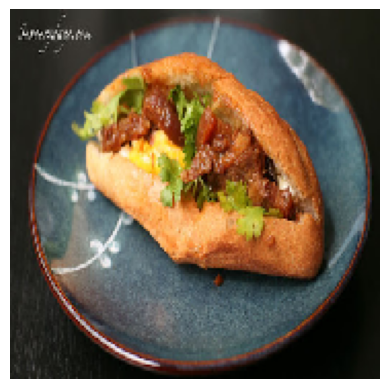

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Món ăn dự đoán: banh_mi
Độ tin cậy: 94.22 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Đổi path này thành ảnh cậu muốn test
img_path = "/content/drive/MyDrive/clean_vietnamese_food/banh_mi/banh_mi_114.jpeg"

img = load_img(img_path, target_size=(180, 180))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

predicted_class = class_names[predicted_index]

print("Món ăn dự đoán:", predicted_class)
print("Độ tin cậy:", round(confidence, 2), "%")

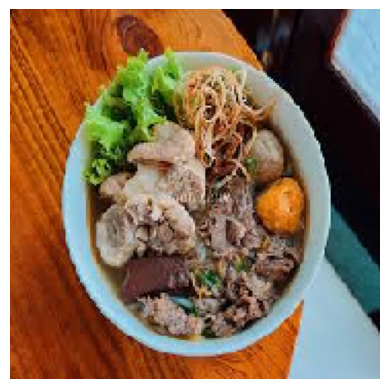

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Món ăn dự đoán: bun_bo_hue
Độ tin cậy: 69.79 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Đổi path này thành ảnh cậu muốn test
img_path = "/content/drive/MyDrive/clean_vietnamese_food/bun_bo_hue/bun_bo_hue_10.jpeg"

img = load_img(img_path, target_size=(180, 180))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

predicted_class = class_names[predicted_index]

print("Món ăn dự đoán:", predicted_class)
print("Độ tin cậy:", round(confidence, 2), "%")

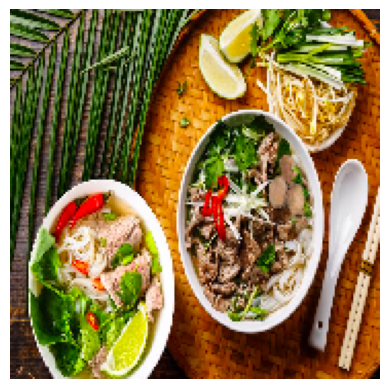

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Món ăn dự đoán: pho
Độ tin cậy: 44.19 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Đổi path này thành ảnh cậu muốn test
img_path = "/content/drive/MyDrive/clean_vietnamese_food/pho/pho_102.png"

img = load_img(img_path, target_size=(180, 180))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

predicted_class = class_names[predicted_index]

print("Món ăn dự đoán:", predicted_class)
print("Độ tin cậy:", round(confidence, 2), "%")

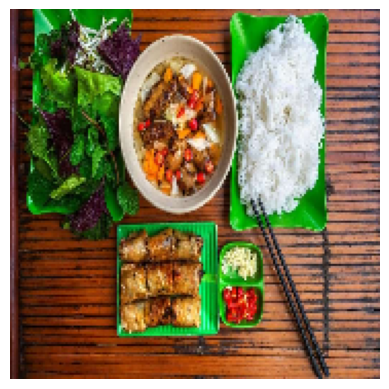

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Món ăn dự đoán: bun_cha_ha_noi
Độ tin cậy: 82.25 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Đổi path này thành ảnh cậu muốn test
img_path = "/content/drive/MyDrive/clean_vietnamese_food/bun_cha_ha_noi/bun_cha_ha_noi_100.jpeg"

img = load_img(img_path, target_size=(180, 180))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

predicted_class = class_names[predicted_index]

print("Món ăn dự đoán:", predicted_class)
print("Độ tin cậy:", round(confidence, 2), "%")